# Consigna actividad individual número 2 - Opcional

Seleccionar uno de los datasets disponibles aquí. Pueden elegir el propio o uno propuesto por un/a compañero/a.

Realizar un EDA básico del dataset seleccionado:

- Estadística descriptiva
- Tipos de variables
- Identificación de duplicados, nulos, outliers
- Incluir al menos 3 gráficos
- Guardarlo en un repositorio de acceso público o en una notebook de Google Colab. Lo importante es que el código esté ejecutado (que muestre la salida).

Se pueden apoyar en las notebooks dadas en clase, o pueden crear su propio código.


# Dataset elegido: Social Media and Mental Health

In [394]:
import pandas as pd
import missingno as msno
import kagglehub
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import sys
sys.path.append('../../utils')
from plotting import plot_histograma
import seaborn as sns


In [395]:

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
path = kagglehub.dataset_download("souvikahmed071/social-media-and-mental-health")
csv_file = next(Path(path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

PosixPath('data/smmh.csv')

In [396]:
data_path = "data/smmh.csv"
df = pd.read_csv(data_path)

# Renombramos columnas, porque son demasiado largas
df.columns = [                                                                                         
      "timestamp",                                                                                       
      "age",                                                                                             
      "gender",                                                                                          
      "relationship_status",                                                                             
      "occupation_status",                                                                               
      "organization_type",                                                                               
      "uses_social_media",                                                                               
      "platforms_used",                       
      "daily_usage_time",                                                                                
      "purposeless_use",
      "distracted_while_busy",                                                                           
      "restlessness",                         
      "easily_distracted",                                                                               
      "bothered_by_worries",
      "concentration_difficulty",                                                                        
      "social_comparison",
      "comparison_feelings",                                                                             
      "validation_seeking",
      "depression_frequency",
      "interest_fluctuation",
      "sleep_issues"
      ] 

df.head()

,timestamp,age,gender,relationship_status,occupation_status,organization_type,uses_social_media,platforms_used,daily_usage_time,purposeless_use,...,restlessness,easily_distracted,bothered_by_worries,concentration_difficulty,social_comparison,comparison_feelings,validation_seeking,depression_frequency,interest_fluctuation,sleep_issues
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


## Información inicial del dataset

In [397]:
df.describe()

,age,purposeless_use,distracted_while_busy,restlessness,easily_distracted,bothered_by_worries,concentration_difficulty,social_comparison,comparison_feelings,validation_seeking,depression_frequency,interest_fluctuation,sleep_issues
count,481.00000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,26.13659,3.553015,3.320166,2.588358,3.349272,3.559252,3.245322,2.831601,2.775468,2.455301,3.255717,3.170478,3.201663
std,9.91511,1.096299,1.328137,1.257059,1.175552,1.283356,1.347105,1.407835,1.056479,1.247739,1.313033,1.256666,1.461619
min,13.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.00000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
50%,22.00000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000
75%,26.00000,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,5.000000
max,91.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [398]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 481 non-null    str    
 1   age                       481 non-null    float64
 2   gender                    481 non-null    str    
 3   relationship_status       481 non-null    str    
 4   occupation_status         481 non-null    str    
 5   organization_type         451 non-null    str    
 6   uses_social_media         481 non-null    str    
 7   platforms_used            481 non-null    str    
 8   daily_usage_time          481 non-null    str    
 9   purposeless_use           481 non-null    int64  
 10  distracted_while_busy     481 non-null    int64  
 11  restlessness              481 non-null    int64  
 12  easily_distracted         481 non-null    int64  
 13  bothered_by_worries       481 non-null    int64  
 14  concentration_difficu

In [399]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")


El dataset tiene 481 filas y 21 columnas.


## Descripción del dataset

| Nombre                     | Descripción                                                    |
| -------------------------- | -------------------------------------------------------------- |
| `timestamp`                | Fecha y hora de la encuesta                                    |
| `age`                      | Edad del encuestado (años)                                     |
| `gender`                   | Género: Male, Female, Non-binary                               |
| `relationship_status`      | Estado civil: Single, Married, Divorced, In a relationship     |
| `occupation_status`        | Ocupación: Student, Employed, Self-Employed, Retired           |
| `organization_type`        | Tipo de organización: University, Company, School              |
| `uses_social_media`        | Usa redes sociales: Yes / No                                   |
| `platforms_used`           | Plataformas usadas: Facebook, Instagram, TikTok, YouTube, etc. |
| `daily_usage_time`         | Tiempo diario en redes: menos de 1h hasta más de 5h            |
| `purposeless_use`          | Uso sin propósito definido (escala 1-5)                        |
| `distracted_while_busy`    | Distracción por redes al trabajar/estudiar (escala 1-5)        |
| `restlessness`             | Inquietud al no usar redes sociales (escala 1-5)               |
| `easily_distracted`        | Nivel general de distracción (escala 1-5)                      |
| `bothered_by_worries`      | Nivel de preocupación o ansiedad (escala 1-5)                  |
| `concentration_difficulty` | Dificultad para concentrarse (escala 1-5)                      |
| `social_comparison`        | Comparación con personas exitosas en redes (escala 1-5)        |
| `comparison_feelings`      | Sentimiento ante esas comparaciones (cualitativa)              |
| `validation_seeking`       | Búsqueda de validación en redes (escala 1-5)                   |
| `depression_frequency`     | Frecuencia de tristeza o depresión (escala 1-5)                |
| `interest_fluctuation`     | Fluctuación del interés en actividades diarias (escala 1-5)    |
| `sleep_issues`             | Problemas de sueño (escala 1-5)                                |


## Tipos de variables

### Cuantitativas (Numéricas)

#### Discretas

_Toman valores enteros_

- 1. What is your age?

#### Continuas

_Pueden tomar cualquier valor dentro de un rango_

- No se encontraron variables contínuas en el dataset

### Categóricas (cualitativas o atributos)

#### Nominales

_Sin orden_

- 2. Gender
- 3. Relationship Status
- 4. Occupation Status
- 5. What type of organizations are you affiliated with?
- 6. Do you use social media?
- 7. What social media platforms do you commonly use?

#### Ordinales

_Tienen un órden específico_

- 8. What is the average time you spend on social media every day?
- 9. How often do you find yourself using Social media without a specific purpose?
- 10. How often do you get distracted by Social media when you are busy doing something?
- 11. Do you feel restless if you haven't used Social media in a while?
- 12. On a scale of 1 to 5, how easily distracted are you?
- 13. On a scale of 1 to 5, how much are you bothered by worries?
- 14. Do you find it difficult to concentrate on things?
- 15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?
- 16. Following the previous question, how do you feel about these comparisons, generally speaking?
- 17. How often do you look to seek validation from features of social media?
- 18. How often do you feel depressed or down?
- 19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?
- 20. On a scale of 1 to 5, how often do you face issues regarding sleep?


## Estadística descriptiva

### Media - Mediana - Moda

In [400]:
print(f"Media:   {df['age'].mean():.1f}")                                                              
print(f"Mediana: {df['age'].median():.1f}")                                                            
print(f"Moda:    {df['age'].mode()[0]}")

Media:   26.1
Mediana: 22.0
Moda:    21.0


#### Histograma de la distribución de edad

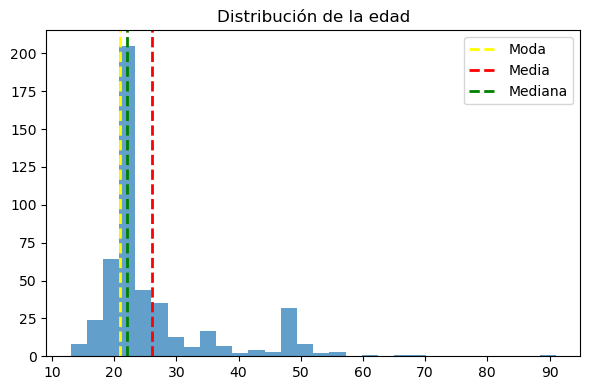

In [401]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['age'], bins=30, alpha=0.7)
ax.axvline(df['age'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(df['age'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(df['age'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Distribución de la edad')
ax.legend()

plt.tight_layout()
plt.show()

### Media - Varianza - Desvío estándar

Estadísticas descriptivas de la variable 'age':
  • Media:     26.14 años
  • Varianza:  98.3094 años
  • Desv. Est.: 9.9151 años


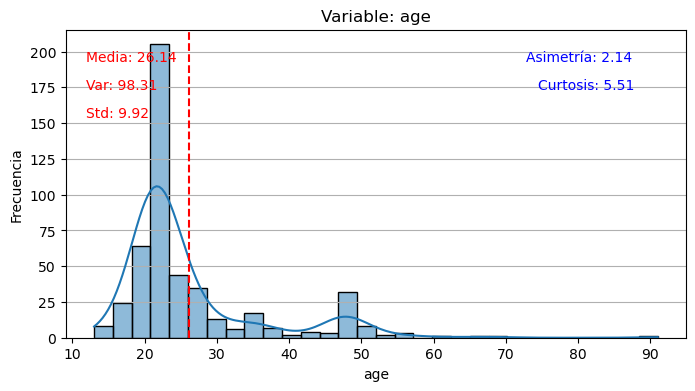

In [402]:
# Calculamos la media, varianza y desviación estándar de la edad
media = df['age'].mean()
var = df['age'].var()
std_dev = df['age'].std()

print(f"Estadísticas descriptivas de la variable 'age':")
print(f"  • Media:     {media:.2f} años")
print(f"  • Varianza:  {var:.4f} años")
print(f"  • Desv. Est.: {std_dev:.4f} años")

# Graficamos la distribución de la edad
plot_histograma(df, 'age', figsize=(8, 4), bins=30, kde=True, mvd=True, snk=True)

## Identificación de duplicados, nulos, outliers

### Nulos

In [403]:
df.isnull().sum()

timestamp                    0
age                          0
gender                       0
relationship_status          0
occupation_status            0
organization_type           30
uses_social_media            0
platforms_used               0
daily_usage_time             0
purposeless_use              0
distracted_while_busy        0
restlessness                 0
easily_distracted            0
bothered_by_worries          0
concentration_difficulty     0
social_comparison            0
comparison_feelings          0
validation_seeking           0
depression_frequency         0
interest_fluctuation         0
sleep_issues                 0
dtype: int64

<Axes: >

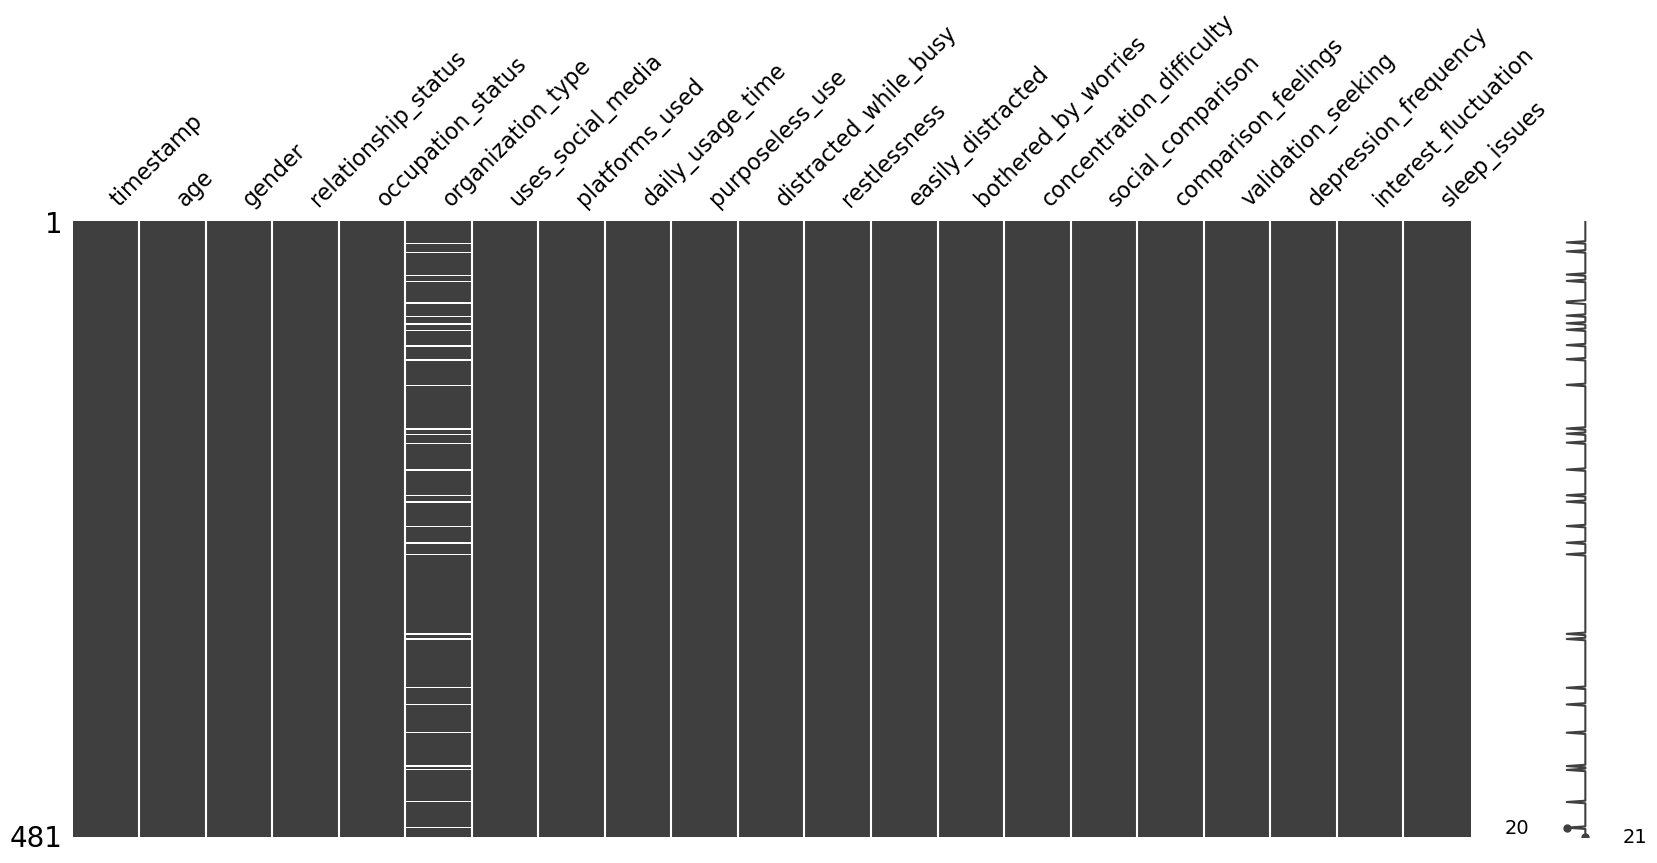

In [404]:
msno.matrix(df, figsize=(20,8))

In [405]:
nulls = df["organization_type"].isnull().sum()                                                         
pct = df["organization_type"].isnull().mean() * 100                                                  
                                                                                                         
print(f"La única columna con nulos es organization_type, con {nulls} valores nulos que representan el  {pct:.2f}% del total")                                                                                 
                         

La única columna con nulos es organization_type, con 30 valores nulos que representan el  6.24% del total


### Duplicados

In [406]:
print("Cantidad de datos duplicados:", df.duplicated().sum())

Cantidad de datos duplicados: 0


### Outliers

#### Basado en el rango intercuartil

In [407]:
outliers_df = df["age"]

In [408]:
# Métodos estadísticos para detectar outliers
Q1 = outliers_df.quantile(0.25)
Q3 = outliers_df.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (outliers_df < (Q1 - 1.5 * IQR)) | (outliers_df > (Q3 + 1.5 * IQR))
print(f"Outliers\nAge: <{Q1 - 1.5 * IQR:.02f} o >{Q3 + 1.5 * IQR:.02f}")

Outliers
Age: <13.50 o >33.50


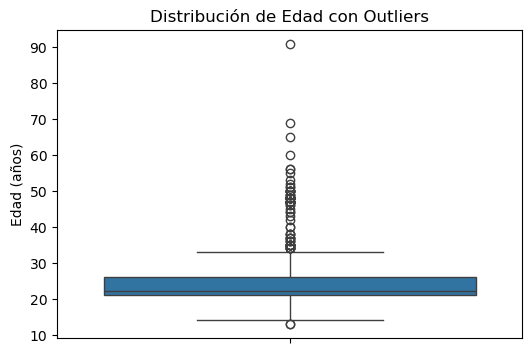

In [409]:
# Visualización de outliers con boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['age'])
plt.title('Distribución de Edad con Outliers')
plt.ylabel('Edad (años)')
plt.show()

#### Basado en la desviación estándar

In [410]:
mean = df["age"].mean()
std = df["age"].std()
                                                                                                         
outliers_std = (df["age"] < (mean - 3 * std)) | (df["age"] > (mean + 3 * std))                         
                                                                                                         
print(f"Outliers Age: <{mean - 3 * std:.2f} o >{mean + 3 * std:.2f}")  

Outliers Age: <-3.61 o >55.88


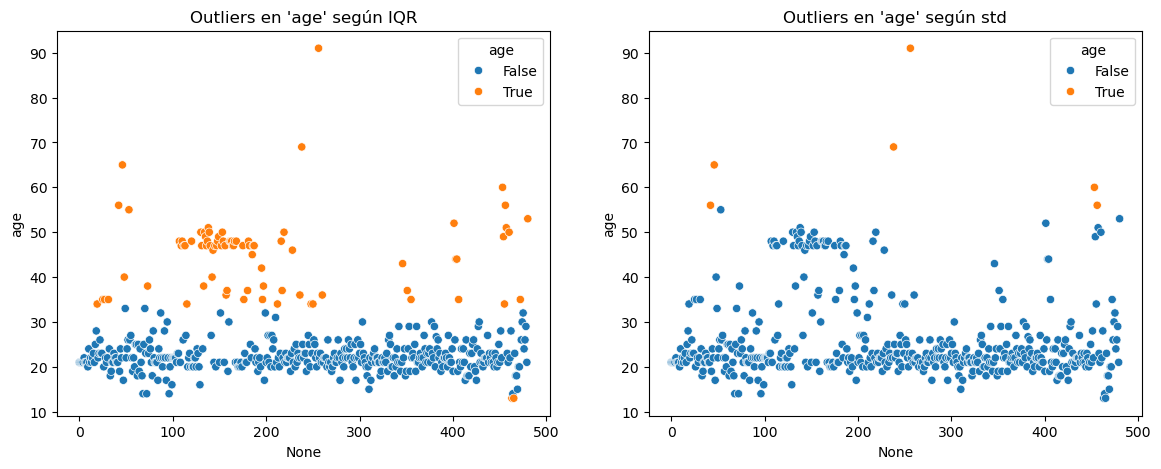

In [411]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df.index, y=df["age"], hue=outliers_iqr, ax=ax[0])                                   
ax[0].set_title("Outliers en 'age' según IQR")
sns.scatterplot(x=df.index, y=df["age"], hue=outliers_std, ax=ax[1])                                   
ax[1].set_title("Outliers en 'age' según std")                                                         
plt.show()

## Análisis entre variables

### Tiempo de uso vs edad

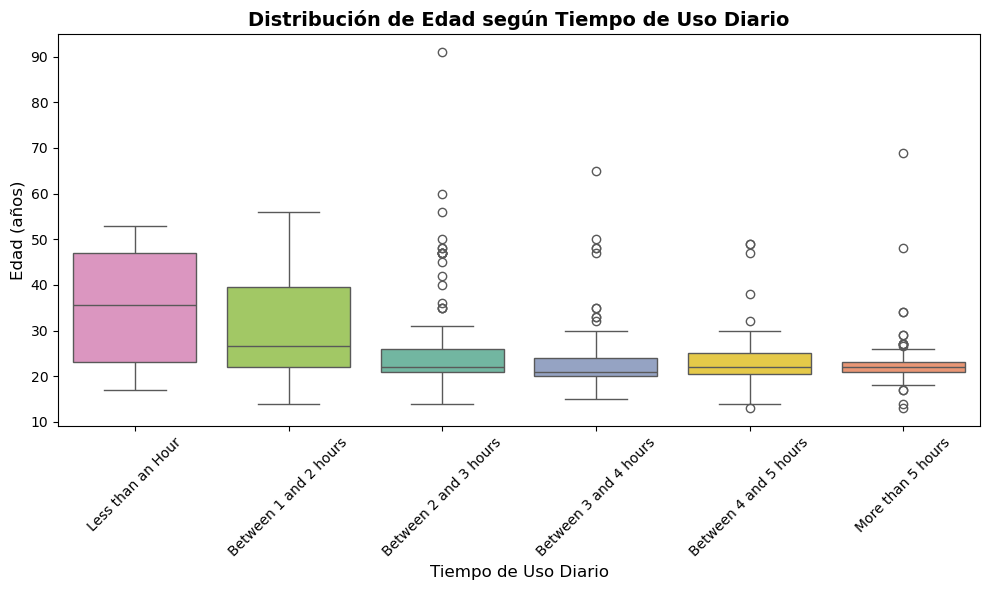

In [412]:
order = [                                                                                              
    "Less than an Hour",                                                                               
    "Between 1 and 2 hours",                                                                           
    "Between 2 and 3 hours",                                                                           
    "Between 3 and 4 hours",                                                                           
    "Between 4 and 5 hours",
    "More than 5 hours"                                                                                
]                                                                                                      
                                                                                                        
fig, ax = plt.subplots(figsize=(10, 6))                                                                


sns.boxplot(data=df, x="daily_usage_time", y="age", ax=ax, palette="Set2", order=order, hue="daily_usage_time", legend=False)

ax.set_title("Distribución de Edad según Tiempo de Uso Diario", fontsize=14, fontweight="bold")        
ax.set_xlabel("Tiempo de Uso Diario", fontsize=12)                                                     
ax.set_ylabel("Edad (años)", fontsize=12)                                                              
ax.tick_params(axis="x", rotation=45)                                                                  
plt.tight_layout()                                                                                     
plt.show()                                                                                             
        

### Edad vs facebook

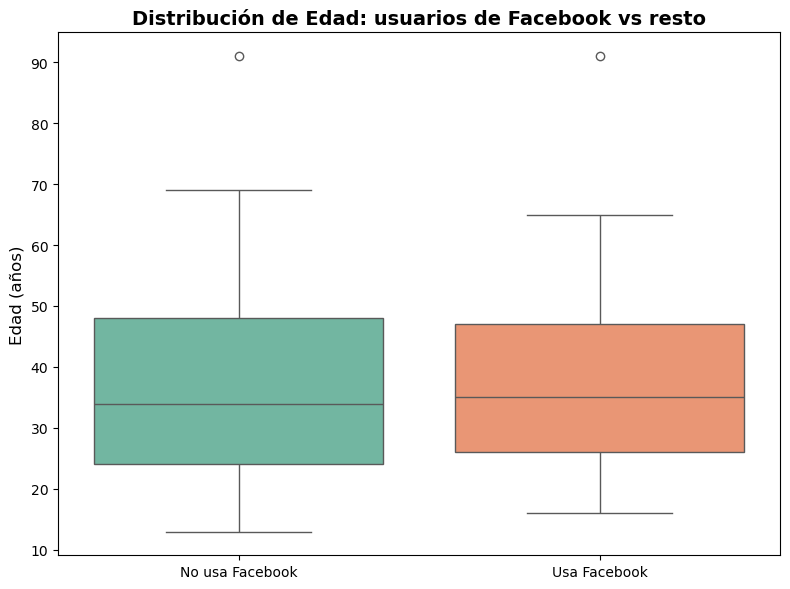

In [ ]:
df_platforms = df[["age", "platforms_used"]].copy()                                                    
df_platforms["platforms_used"] = df_platforms["platforms_used"].str.split(", ")                        
df_platforms = df_platforms.explode("platforms_used")                                                  
                                                                                                        
df_platforms["uses_facebook"] = df_platforms["platforms_used"] == "Facebook"                           
                
fig, ax = plt.subplots(figsize=(8, 6))                                                                 
sns.boxplot(data=df_platforms.drop_duplicates(subset=["age", "uses_facebook"]),
            x="uses_facebook", y="age", ax=ax,                                                         
            hue="uses_facebook", legend=False, palette="Set2")  

ax.set_xticks([0, 1])                                                                                  

ax.set_xticklabels(["No usa Facebook", "Usa Facebook"])                                                
ax.set_title("Distribución de Edad: usuarios de Facebook", fontsize=14, fontweight="bold")    
ax.set_xlabel("")                                                                                      
ax.set_ylabel("Edad (años)", fontsize=12)                                                              
plt.tight_layout()                                                                                     
plt.show()    